### __Data Dictionary__

The dataset contains 3-hourly weather readings from five Spanish cities — Madrid, Seville, Valencia, Bilbao, and Barcelona — alongside the corresponding energy shortfall.

**Target variable**
- `load_shortfall_3h`: The shortfall between fossil fuel and renewable energy generation over 3 hours (Float). This is what we are predicting.

**Weather features (per city)**
- `{city}_temp`: Average temperature in Kelvin (Float).
- `{city}_humidity`: Relative humidity as a percentage (Float).
- `{city}_wind_speed`: Wind speed in m/s (Float).
- `{city}_pressure`: Atmospheric pressure in hPa (Float, except `Seville_pressure` which is categorical string).
- `{city}_clouds_all`: Cloud coverage as a percentage (Float).

**Columns requiring preprocessing**
- `Valencia_wind_deg`: Encoded as string levels (`level_1` through `level_10`) — extract the numeric value.
- `Seville_pressure`: Encoded as strings (`sp1` through `sp25`) — extract the numeric value.
- `Valencia_pressure`: Contains approximately 2,000 missing values — rows will be dropped.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

In [2]:
file_path = 'df_train.csv'  # Replace with your file path
df_raw = pd.read_csv(file_path, index_col=0)

# Preprocess: extract numeric values from categorical-encoded columns, drop nulls
df = df_raw.copy()
df = df.drop(columns=['time'], errors='ignore')
df['Valencia_wind_deg'] = df['Valencia_wind_deg'].str.extract(r'(\d+)').astype(float)
df['Seville_pressure']  = df['Seville_pressure'].str.extract(r'(\d+)').astype(float)
df = df.dropna()

In [4]:
print(df_raw.columns.tolist())

['time', 'Madrid_wind_speed', 'Valencia_wind_deg', 'Bilbao_rain_1h', 'Valencia_wind_speed', 'Seville_humidity', 'Madrid_humidity', 'Bilbao_clouds_all', 'Bilbao_wind_speed', 'Seville_clouds_all', 'Bilbao_wind_deg', 'Barcelona_wind_speed', 'Barcelona_wind_deg', 'Madrid_clouds_all', 'Seville_wind_speed', 'Barcelona_rain_1h', 'Seville_pressure', 'Seville_rain_1h', 'Bilbao_snow_3h', 'Barcelona_pressure', 'Seville_rain_3h', 'Madrid_rain_1h', 'Barcelona_rain_3h', 'Valencia_snow_3h', 'Madrid_weather_id', 'Barcelona_weather_id', 'Bilbao_pressure', 'Seville_weather_id', 'Valencia_pressure', 'Seville_temp_max', 'Madrid_pressure', 'Valencia_temp_max', 'Valencia_temp', 'Bilbao_weather_id', 'Seville_temp', 'Valencia_humidity', 'Valencia_temp_min', 'Barcelona_temp_max', 'Madrid_temp_max', 'Barcelona_temp', 'Bilbao_temp_min', 'Bilbao_temp', 'Barcelona_temp_min', 'Bilbao_temp_max', 'Seville_temp_min', 'Madrid_temp', 'Madrid_temp_min', 'load_shortfall_3h']


In [5]:
print(df["Valencia_wind_deg"].head())
print(df["Valencia_wind_deg"].dtype)

0     5.0
1    10.0
2     9.0
3     8.0
6     8.0
Name: Valencia_wind_deg, dtype: float64
float64


In [3]:
df.head()

,Madrid_wind_speed,Valencia_wind_deg,Bilbao_rain_1h,Valencia_wind_speed,Seville_humidity,Madrid_humidity,Bilbao_clouds_all,Bilbao_wind_speed,Seville_clouds_all,Bilbao_wind_deg,...,Madrid_temp_max,Barcelona_temp,Bilbao_temp_min,Bilbao_temp,Barcelona_temp_min,Bilbao_temp_max,Seville_temp_min,Madrid_temp,Madrid_temp_min,load_shortfall_3h
0,0.666667,5.0,0.0,0.666667,74.333333,64.000000,0.000000,1.0,0.0,223.333333,...,265.938000,281.013000,269.338615,269.338615,281.013000,269.338615,274.254667,265.938000,265.938000,6715.666667
1,0.333333,10.0,0.0,1.666667,78.333333,64.666667,0.000000,1.0,0.0,221.000000,...,266.386667,280.561667,270.376000,270.376000,280.561667,270.376000,274.945000,266.386667,266.386667,4171.666667
2,1.000000,9.0,0.0,1.000000,71.333333,64.333333,0.000000,1.0,0.0,214.333333,...,272.708667,281.583667,275.027229,275.027229,281.583667,275.027229,278.792000,272.708667,272.708667,4274.666667
3,1.000000,8.0,0.0,1.000000,65.333333,56.333333,0.000000,1.0,0.0,199.666667,...,281.895219,283.434104,281.135063,281.135063,283.434104,281.135063,285.394000,281.895219,281.895219,5075.666667
6,1.000000,8.0,0.0,1.000000,83.666667,63.333333,16.333333,1.0,0.0,210.333333,...,268.287000,283.420333,274.295437,274.295437,283.420333,274.295437,277.637000,268.287000,268.287000,10760.333333


In [4]:
print(df.shape)

(6695, 47)


In [5]:
#import pyperclip

In [6]:
#data = df
#csv_string = data.to_csv(index=False)
# Copy to clipboard
#pyperclip.copy(csv_string)

#print("CSV copied to clipboard!")

---
#### __Challenge 1: Fitting a Multiple Linear Regression Model__

Temperature is recorded across all five cities in our dataset. Rather than choosing just one city's temperature as we did in Part A, we can bring all five in simultaneously. This allows the model to learn the *combined* influence of temperature conditions across Spain — Madrid's continental climate, Seville's heat, the coastal moderation in Barcelona.

#### __Task__
Create a function named `fit_temperature_mlr` that:
- Takes a DataFrame as input.
- Uses the following five features as predictors: `Madrid_temp`, `Seville_temp`, `Valencia_temp`, `Bilbao_temp`, `Barcelona_temp`.
- Fits a multiple linear regression model on the **full dataset**.
- Returns a tuple `(model, r2, rmse)` containing the fitted model object, R-squared on the full dataset, and RMSE on the full dataset.

**Note:**
- Use `LinearRegression` from `sklearn.linear_model`.
- Return format: `(model, r2, rmse)`.

#### __Expected Output__
```
R-squared: 0.06820610764408985
RMSE: 5091.726004672317
Coefficients: {'Madrid_temp': np.float64(121.5574), 'Seville_temp': np.float64(-78.9912), 'Valencia_temp': np.float64(-6.8158), 'Bilbao_temp': np.float64(29.1241), 'Barcelona_temp': np.float64(113.1248)}
```

In [9]:
### START FUNCTION
def fit_temperature_mlr(df):

    # Define predictors
    features = [
        "Madrid_temp",
        "Seville_temp",
        "Valencia_temp",
        "Bilbao_temp",
        "Barcelona_temp"
    ]

    # Predictor variables
    X = df[features]

    # Target variable
    y = df["load_shortfall_3h"]

    # Fit model on the full dataset
    model = LinearRegression()
    model.fit(X, y)

    # Predictions on the full dataset
    y_pred = model.predict(X)

    # Calculate evaluation metrics
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    return model, r2, rmse

In [10]:
model, r2, rmse = fit_temperature_mlr(df)

print(f"R-squared: {r2}")
print(f"RMSE: {rmse}")

features = [
    "Madrid_temp",
    "Seville_temp",
    "Valencia_temp",
    "Bilbao_temp",
    "Barcelona_temp"
]

coefficients = dict(zip(features, model.coef_))

print("Coefficients:", coefficients)

R-squared: 0.06820610764408985
RMSE: 5091.726004672317
Coefficients: {'Madrid_temp': np.float64(121.55735432577858), 'Seville_temp': np.float64(-78.99122557674418), 'Valencia_temp': np.float64(-6.815797708430121), 'Bilbao_temp': np.float64(29.12409850109001), 'Barcelona_temp': np.float64(113.12478652828935)}


---
#### __Challenge 2: Diagnosing Multicollinearity with VIF__

Before trusting any coefficient in an MLR model, we need to check for **multicollinearity** — the condition where two or more predictors are highly correlated with each other. When predictors move together, the model cannot isolate each one's individual contribution, and coefficients become statistically unstable.

The **Variance Inflation Factor (VIF)** measures this directly. For each predictor, VIF answers: "How much larger is the variance of this coefficient than it would be if this predictor were uncorrelated with all the others?"

**Rules of thumb:**
- VIF < 5: Low multicollinearity — acceptable.
- VIF 5–10: Moderate — worth monitoring.
- VIF > 10: High — the predictor is likely redundant.

#### __Task__
Create a function named `calculate_vif` that:
- Takes a DataFrame and a list of feature column names as input.
- Calculates the VIF for each feature.
- Returns a DataFrame with columns `feature` and `VIF`, sorted by VIF in descending order with the index reset.

**Note:** Use `variance_inflation_factor` from `statsmodels.stats.outliers_influence`.

#### __Expected Output__
```
          feature           VIF
0   Valencia_temp  14491.975682
1  Barcelona_temp  12796.330493
2    Seville_temp   9105.434827
3     Bilbao_temp   8624.932391
4     Madrid_temp   7006.728704
```

In [11]:
def calculate_vif(df, feature_cols):

    # Select the predictor variables
    X = df[feature_cols]

    # Calculate VIF for each feature
    vif_data = pd.DataFrame({
        "feature": feature_cols,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    # Sort by VIF in descending order
    vif_data = (
        vif_data
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

    return vif_data

In [12]:
features = [
    "Madrid_temp",
    "Seville_temp",
    "Valencia_temp",
    "Bilbao_temp",
    "Barcelona_temp"
]

vif_results = calculate_vif(df, features)

vif_results

,feature,VIF
0,Valencia_temp,14491.975682
1,Barcelona_temp,12796.330493
2,Seville_temp,9105.434827
3,Bilbao_temp,8624.932391
4,Madrid_temp,7006.728704


#### __Key point__

These VIF values are extremely high. Since all five are far above 10, there is severe multicollinearity among the city temperatures.

This makes sense geographically: temperatures across Spanish cities tend to move together according to broader weather patterns. As a result, the individual MLR coefficients from Challenge 1 should be interpreted cautiously.

---
#### __Challenge 3: Train-Test Split and Performance Evaluation__

Fitting and evaluating on the same data, as we did in Challenge 1, can give an overly optimistic view of performance. A model that has seen every training example can fit those points closely, but then fail when it encounters new data it has never seen.

The train-test split gives us an honest estimate: train on 80%, evaluate on the held-out 20%. If test performance is close to training performance, the model is generalizing. If test performance is dramatically worse, the model is overfitting.

#### __Task__
Create a function named `mlr_train_test_evaluate` that:
- Takes a DataFrame as input.
- Uses `Madrid_temp`, `Seville_temp`, `Valencia_temp`, `Bilbao_temp`, `Barcelona_temp` as predictors and `load_shortfall_3h` as the target.
- Splits the data with `test_size=0.2` and `random_state=42`.
- Trains on the training set, evaluates on the test set.
- Returns `(r2, rmse), (predictions, y_test)`.

**Note:** The second tuple `(predictions, y_test)` will be used directly in Challenges 4 and 5.

#### __Expected Output__
```
Test R-squared: 0.07184913973567075
Test RMSE: 5098.7257157969025
```

In [13]:
def mlr_train_test_evaluate(df):

    # Define the five temperature predictors
    features = [
        "Madrid_temp",
        "Seville_temp",
        "Valencia_temp",
        "Bilbao_temp",
        "Barcelona_temp"
    ]

    # Predictors and target
    X = df[features]
    y = df["load_shortfall_3h"]

    # Split into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Evaluate test-set performance
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    return (r2, rmse), (predictions, y_test)

In [14]:
(r2, rmse), (predictions, y_test) = mlr_train_test_evaluate(df)

print(f"Test R-squared: {r2}")
print(f"Test RMSE: {rmse}")

Test R-squared: 0.07184913973567075
Test RMSE: 5098.7257157969025


#### __Challenge 4: Checking Residual Independence — Durbin-Watson__

Our dataset is a **time series** — energy readings recorded every 3 hours over multiple years. This creates a specific risk: the error our model makes at 9 a.m. might predict the error it makes at noon. If residuals are correlated across time (**autocorrelation**), the independence assumption of linear regression is violated, and our standard errors — and therefore our p-values and confidence intervals — are unreliable.

The **Durbin-Watson statistic** detects this. It ranges from 0 to 4:

| Value | Interpretation |
|---|---|
| ~2 | No autocorrelation — independence assumption holds ✅ |
| < 1.5 | Positive autocorrelation — model is missing a time trend |
| > 2.5 | Negative autocorrelation — over-correction between consecutive residuals |

#### __Task__
Create a function named `check_residual_independence` that:
- Takes `predictions` and `y_test` (from Challenge 3).
- Calculates the residuals as `y_test - predictions`.
- Computes and returns the Durbin-Watson statistic as a float.

**Note:** Use `durbin_watson` from `statsmodels.stats.stattools`.

#### __Expected Output__
```
Durbin-Watson statistic: 1.9733091268157688
```

In [15]:
def check_residual_independence(predictions, y_test):

    # Calculate residuals
    residuals = y_test - predictions

    # Calculate Durbin-Watson statistic
    dw_statistic = durbin_watson(residuals)

    return float(dw_statistic)

In [16]:
dw_statistic = check_residual_independence(predictions, y_test)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.9733091268157683


#### __Interpretation__

Since the statistic is approximately 2:

**DW ≈ 1.97 → little to no evidence of autocorrelation.**

So, based on the Durbin-Watson test, the residual independence assumption appears reasonable for this model.

#### __Challenge 5: Assessing Homoscedasticity — Residuals vs. Fitted__

The final diagnostic we need is **homoscedasticity**: the assumption that the variance of residuals is roughly constant across all predicted values. A model that is highly accurate at low predicted values but wildly off at high predicted values violates this assumption — and tells us the model structure is missing something.

The standard check is a scatter plot of residuals against fitted values (predictions). In a well-specified model, this plot should look like a horizontal band of roughly equal scatter around the zero line, with no obvious funnel, curve, or cluster.

### __Task__
Create a function named `plot_residuals_vs_fitted` that:
- Takes `predictions` and `y_test` (from Challenge 3).
- Calculates residuals as `y_test - predictions`.
- Creates a scatter plot of residuals (y-axis) against fitted values (x-axis), with a horizontal red dashed line at zero, axis labels, and a title.
- Returns a tuple `(mean_residual, std_residual)`.

### __Expected Output__
```
Mean residual: -145.18258649860152
Std of residuals: 5096.658311237494
```

In [32]:
def plot_residuals_vs_fitted(predictions, y_test):

    # Calculate residuals
    residuals = y_test - predictions

    # Create residuals vs fitted plot
    plt.figure(figsize=(8, 4))
    plt.scatter(predictions, residuals, color="darkorange", alpha = 0.65)
    plt.axhline(
        y=0,
        color="grey",
        linestyle="--",
        lw = 2
    )

    # Labels and title
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Fitted Values")

    plt.show()

    # Calculate residual statistics
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals, ddof=1)

    return mean_residual, std_residual

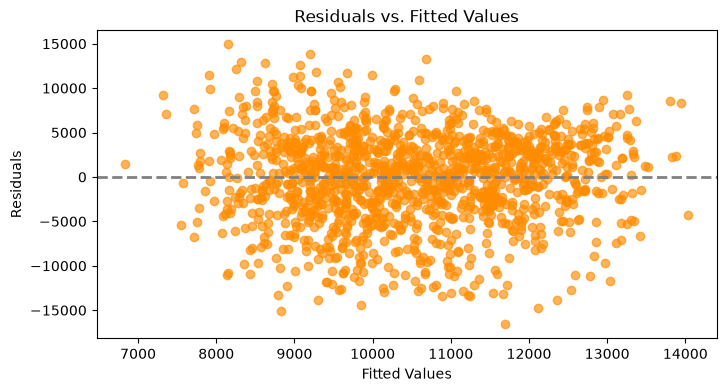

Mean residual: -145.18258649860826
Std of residuals: 5098.562536340826


In [33]:
mean_residual, std_residual = plot_residuals_vs_fitted(
    predictions,
    y_test
)

print(f"Mean residual: {mean_residual}")
print(f"Std of residuals: {std_residual}")

#### __Interpretation__
- __Mean residual ≈ -145: close to zero, so there is little overall bias in the predictions.__
- __Std ≈ 5,096.66: the residuals have substantial spread.__
- __For homoscedasticity, the important visual check is whether the scatter has a roughly constant vertical spread across fitted values, without a funnel or systematic curve.__